In [40]:
#Importación de librerías a utilizar 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [41]:
#Creo un dataframe con los datos del excel de la letra
df=pd.read_excel("../smoking_prediction.xlsx")

In [42]:
#Empiezo la exploración del dataset (EDA)
df.head(3)

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),...,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,...,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,...,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,...,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1


In [43]:
df.shape

(50000, 27)

In [44]:
#Vemos que no hay nulos y los tipos de datos que hay en cada columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   50000 non-null  int64  
 1   gender               50000 non-null  object 
 2   age                  50000 non-null  int64  
 3   height(cm)           50000 non-null  int64  
 4   weight(kg)           50000 non-null  int64  
 5   waist(cm)            50000 non-null  float64
 6   eyesight(left)       50000 non-null  float64
 7   eyesight(right)      50000 non-null  float64
 8   hearing(left)        50000 non-null  float64
 9   hearing(right)       50000 non-null  float64
 10  systolic             50000 non-null  float64
 11  relaxation           50000 non-null  float64
 12  fasting blood sugar  50000 non-null  float64
 13  Cholesterol          50000 non-null  float64
 14  triglyceride         50000 non-null  float64
 15  HDL                  50000 non-null 

In [45]:
#Verificamos nuevamente los nulos
df.isna().sum()/df.shape[0]*100

ID                     0.0
gender                 0.0
age                    0.0
height(cm)             0.0
weight(kg)             0.0
waist(cm)              0.0
eyesight(left)         0.0
eyesight(right)        0.0
hearing(left)          0.0
hearing(right)         0.0
systolic               0.0
relaxation             0.0
fasting blood sugar    0.0
Cholesterol            0.0
triglyceride           0.0
HDL                    0.0
LDL                    0.0
hemoglobin             0.0
Urine protein          0.0
serum creatinine       0.0
AST                    0.0
ALT                    0.0
Gtp                    0.0
oral                   0.0
dental caries          0.0
tartar                 0.0
smoking                0.0
dtype: float64

In [46]:
# Veo si la distribución de la muestra entre fumadores y no fumadores es compatible de estudio. Vemos que la proporción es adecuada para avanzar.
df.smoking.value_counts(normalize=True)*100

smoking
0    63.342
1    36.658
Name: proportion, dtype: float64

In [47]:
#Creo un IMC para ver si le logro sacar valor a las variables peso y altura que en sí mismas no aportar información relevante.
df["IMC"] = df["weight(kg)"] / (df["height(cm)"] / 100) ** 2

In [48]:
#Codificación y creación de train y test y dropeo la variable ID ya que no aporta valor predictivo y solo genera ruido en el modelo. También elimino oral ya que al ser siempre "Y" no aporta información relevante y solo genera ruido. Elimino weight y height porque las usé en IMC.
X = df.drop(["smoking", "ID", "oral", "weight(kg)", "height(cm)"], axis=1).copy()
y = df.smoking.copy()
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


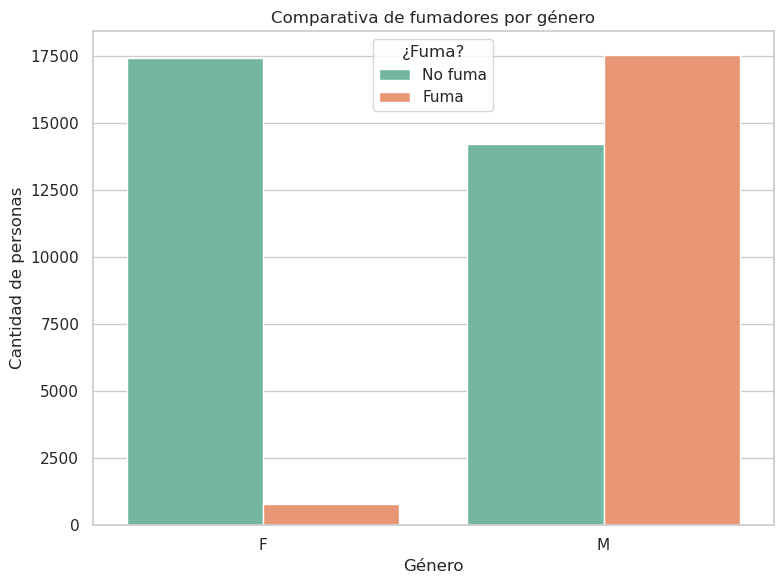

In [49]:
#Voy a hacer uan gráfica para poder representar y entender un poco mejor la composición de fumadores y no fumadores. Vemos que hay un desbalance de fumadores y no fumadores entre hombres y mujeres.
conteo = df.groupby(['gender', 'smoking']).size().reset_index(name='count')
conteo['smoking'] = conteo['smoking'].map({0: 'No fuma', 1: 'Fuma'})
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(data=conteo, x='gender', y='count', hue='smoking', palette='Set2')
plt.title('Comparativa de fumadores por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de personas')
plt.legend(title='¿Fuma?')
plt.tight_layout()
plt.show()


In [50]:
#Empiezo la depuración en train creando variables dummies de las columnas object para que puedan utilizarse en un clasifier.
from sklearn.preprocessing import OneHotEncoder

In [51]:
ohe = OneHotEncoder(sparse_output=False).fit(X_train[["tartar", "gender"]])

In [52]:
encoded = ohe.transform((X_train[["tartar", "gender"]]))

In [53]:
encoded_df = pd.DataFrame(columns=ohe.get_feature_names_out(), data = encoded, index=X_train.index)

In [54]:
X_train = pd.concat([X_train, encoded_df], axis="columns")

In [55]:
X_train = X_train.drop(["tartar", "gender"], axis=1)

In [56]:
#Replico el trabajo hecho con las dummies en el test
encoded_test = ohe.transform((X_test[["tartar", "gender"]]))

In [57]:
encoded_df_test = pd.DataFrame(columns=ohe.get_feature_names_out(), data = encoded_test, index=X_test.index)

In [58]:
X_test = pd.concat([X_test, encoded_df_test], axis="columns")

In [59]:
X_test = X_test.drop(["tartar", "gender"], axis=1)

In [60]:
#Chequeo que ahora todas las variables sean compatibles on los árboles
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35000 entries, 8319 to 43737
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  35000 non-null  int64  
 1   waist(cm)            35000 non-null  float64
 2   eyesight(left)       35000 non-null  float64
 3   eyesight(right)      35000 non-null  float64
 4   hearing(left)        35000 non-null  float64
 5   hearing(right)       35000 non-null  float64
 6   systolic             35000 non-null  float64
 7   relaxation           35000 non-null  float64
 8   fasting blood sugar  35000 non-null  float64
 9   Cholesterol          35000 non-null  float64
 10  triglyceride         35000 non-null  float64
 11  HDL                  35000 non-null  float64
 12  LDL                  35000 non-null  float64
 13  hemoglobin           35000 non-null  float64
 14  Urine protein        35000 non-null  float64
 15  serum creatinine     35000 non-null  f

In [61]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 28092 to 9154
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  int64  
 1   waist(cm)            15000 non-null  float64
 2   eyesight(left)       15000 non-null  float64
 3   eyesight(right)      15000 non-null  float64
 4   hearing(left)        15000 non-null  float64
 5   hearing(right)       15000 non-null  float64
 6   systolic             15000 non-null  float64
 7   relaxation           15000 non-null  float64
 8   fasting blood sugar  15000 non-null  float64
 9   Cholesterol          15000 non-null  float64
 10  triglyceride         15000 non-null  float64
 11  HDL                  15000 non-null  float64
 12  LDL                  15000 non-null  float64
 13  hemoglobin           15000 non-null  float64
 14  Urine protein        15000 non-null  float64
 15  serum creatinine     15000 non-null  f

<Axes: >

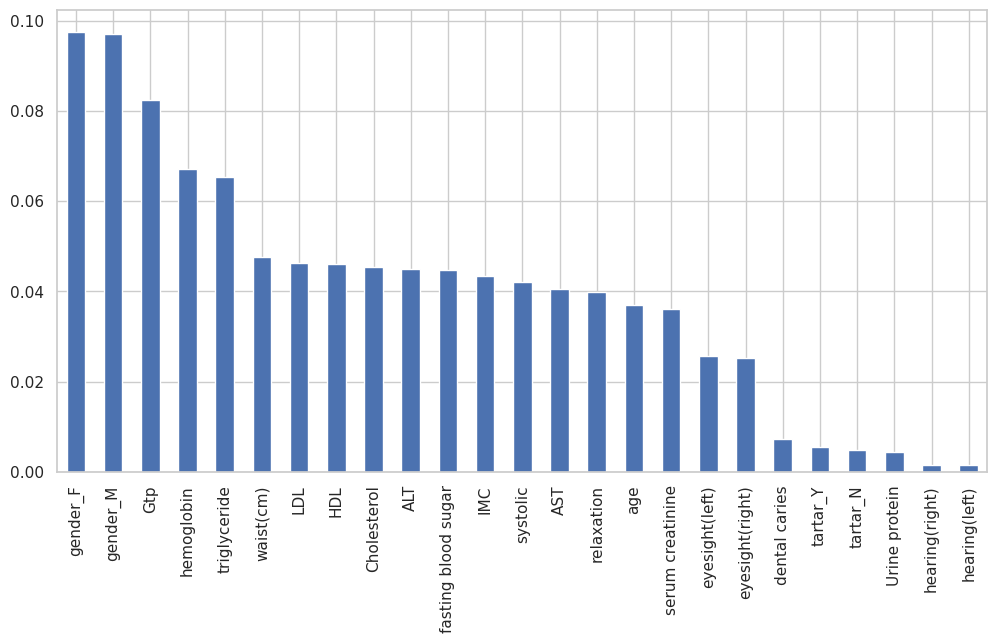

In [62]:
#Empiezo un featuring selection para un random forest, para luego hacer un modelo con las variables más relevantes.
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
importancias = pd.Series(model.feature_importances_, index=X_train.columns)
importancias.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))


In [63]:
#Creo el modelo de random forest con valores de parámetros elegidos a ojo, buscando siempre reducir el overfitting y aumentar el Accuracy.
clf = RandomForestClassifier(n_estimators=300, min_samples_split=44, min_samples_leaf=4, max_depth=12, random_state=42)

In [64]:
#Entreno el modelo
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, min_samples_leaf=4, min_samples_split=44,
                       n_estimators=300, random_state=42)

In [65]:
train_pred = clf.predict(X_train)
test_pred = clf.predict(X_test)

In [66]:
#Los resultados fueron similares comparados al modelo de features de mayor importancia, pero seleccionaré el otro porque resulta más eficiente considerando un trabajo a largo plazo.

from sklearn.metrics import classification_report
print("Train")
print(classification_report(y_train, train_pred))
print("----------------------------------------------------------")
print("Test")
print(classification_report(y_test, test_pred))

Train
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     22170
           1       0.74      0.82      0.78     12830

    accuracy                           0.83     35000
   macro avg       0.82      0.83      0.82     35000
weighted avg       0.84      0.83      0.83     35000

----------------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      9501
           1       0.67      0.74      0.70      5499

    accuracy                           0.77     15000
   macro avg       0.75      0.76      0.76     15000
weighted avg       0.78      0.77      0.77     15000



In [67]:
#voy a testear un clf con solo las features de mayor importancia, el resultado fue que este modelo sobreajusta menos en el train.
top_features = importancias.sort_values(ascending=False).head(19).index
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]
model_top = RandomForestClassifier(n_estimators=390, min_samples_split=44, min_samples_leaf=4, max_depth=12, random_state=42)
model_top.fit(X_train_top, y_train)
train_pred_top = model_top.predict(X_train_top)
test_pred_top = model_top.predict(X_test_top)

print("Train")
print(classification_report(y_train, train_pred_top))
print("----------------------------------------------------------")
print("Test")
print(classification_report(y_test, test_pred_top))


Train
              precision    recall  f1-score   support

           0       0.88      0.83      0.86     22170
           1       0.73      0.81      0.77     12830

    accuracy                           0.82     35000
   macro avg       0.81      0.82      0.81     35000
weighted avg       0.83      0.82      0.82     35000

----------------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.84      0.78      0.81      9501
           1       0.66      0.74      0.70      5499

    accuracy                           0.77     15000
   macro avg       0.75      0.76      0.75     15000
weighted avg       0.77      0.77      0.77     15000



In [68]:
#En el random forest con las features de mayor importancia en la precisión vemos que en el train cuando una persona no fumo el modelo acierta un 88% de las veces, mientras que cuando fuma la persona el modelo acierta un 73%, si lo comparamos en el test los no fumadores acierta un 84% y los fumadores un 66%. Con respecto al recall, vemos que en el train acertó en el 83% del total de los que no fuman y un 81% en los que sí, mientras que en el test acertó en el 78% del total de los que no fuman y un 74% en los que sí. Si bien el accuracy da un %82 en el train y un 77% en el test, preocupa que el modelo falla mucho al acertar si la persona es fumadora.

#Voy a realizar lo mismo con XGBOOST con parámetros standard para tener resultados comparables.

In [69]:
from xgboost import XGBClassifier 

In [70]:
clf2 = XGBClassifier()  #creo el modelo

In [71]:
clf2.fit(X_train, y_train) #entreno el modelo

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [72]:
#Hago las prediciones
train_pred2 = clf2.predict(X_train)
test_pred2 = clf2.predict(X_test)

In [73]:
#Veo las analíticas para comparar los resultados
print("Train")
print(classification_report(y_train, train_pred2))
print("----------------------------------------------------------")
print("Test")
print(classification_report(y_test, test_pred2))

Train
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     22170
           1       0.81      0.83      0.82     12830

    accuracy                           0.87     35000
   macro avg       0.86      0.86      0.86     35000
weighted avg       0.87      0.87      0.87     35000

----------------------------------------------------------
Test
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      9501
           1       0.68      0.70      0.69      5499

    accuracy                           0.77     15000
   macro avg       0.75      0.75      0.75     15000
weighted avg       0.77      0.77      0.77     15000



In [74]:
#En el xgboost en la precisión vemos que en el train cuando una persona no fumo el modelo acierta un 90% de las veces, mientras que cuando fuma la persona el modelo acierta un 81%, si lo comparamos en el test los no fumadores acierta un 82% y los fumadores un 68%. Con respecto al recall, vemos que en el train acertó en el 89% del total de los que no fuman y un 83% en los que sí. mientras que en el test acertó en el 81% del total de los que no fuman y un 70% en los que sí. Si bien el accuracy da un %87 en el train y un 77% en el test, preocupa que el modelo falla mucho al acertar si la persona es fumadora al igual que en random forrest.

#Como modelo final a elegir como más eficiente selecciono el Random Forrest con la selección de features (model_top) ya que comparado con el xgboost se nota que tiene similares accuracy pero el random forrest overfittea menos.

In [75]:
#Voy a cargar el DF con lo datos para entrega
df_entrega = pd.read_excel("../smoking_prediction_entrega.xlsx")
df_entrega["IMC"] = df_entrega["weight(kg)"] / (df["height(cm)"] / 100) ** 2

In [76]:
#Trabajo nuevamente el dataset para que pueda trabajar el modelo en las mismas condiciones que el dataset de entrenamiento. Genero las dummies y dropeo las columnas que no se unan. Seleccioné el modelo del Random Forest con las variables relevantes porque fue el modelo que me dió la mejor proporción accuracy en train y test.
encoded_ohe_entrega = ohe.transform(df_entrega[["tartar", "gender"]])
encoded_df_entrega = pd.DataFrame(columns=ohe.get_feature_names_out(), data=encoded_ohe_entrega, index=df_entrega.index)
# Elimino columnas no usadas por el modelo
X_entrega = df_entrega.drop(["ID", "oral", "weight(kg)", "height(cm)", "Urine protein", "dental caries", "hearing(right)", "hearing(left)", "gender", "tartar"], axis=1).copy()

# Uno las dummies
X_entrega_final = pd.concat([X_entrega, encoded_df_entrega], axis=1)

# Reordeno columnas según el modelo y elimino las features no utilizadas
X_entrega_final = X_entrega_final.reindex(columns=model_top.feature_names_in_, fill_value=0)

# Genero las predicciones
predicciones = model_top.predict(X_entrega_final)

# Agrego la columna al DataFrame original
df_entrega["smoking"] = predicciones

In [77]:
#Exporto al excel para la entrega
df_entrega.to_excel("Entrega.xlsx", index=False)